In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [107]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, auc
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize

In [4]:
df = pd.read_csv("11-iris.csv")

In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [9]:
#seaborn

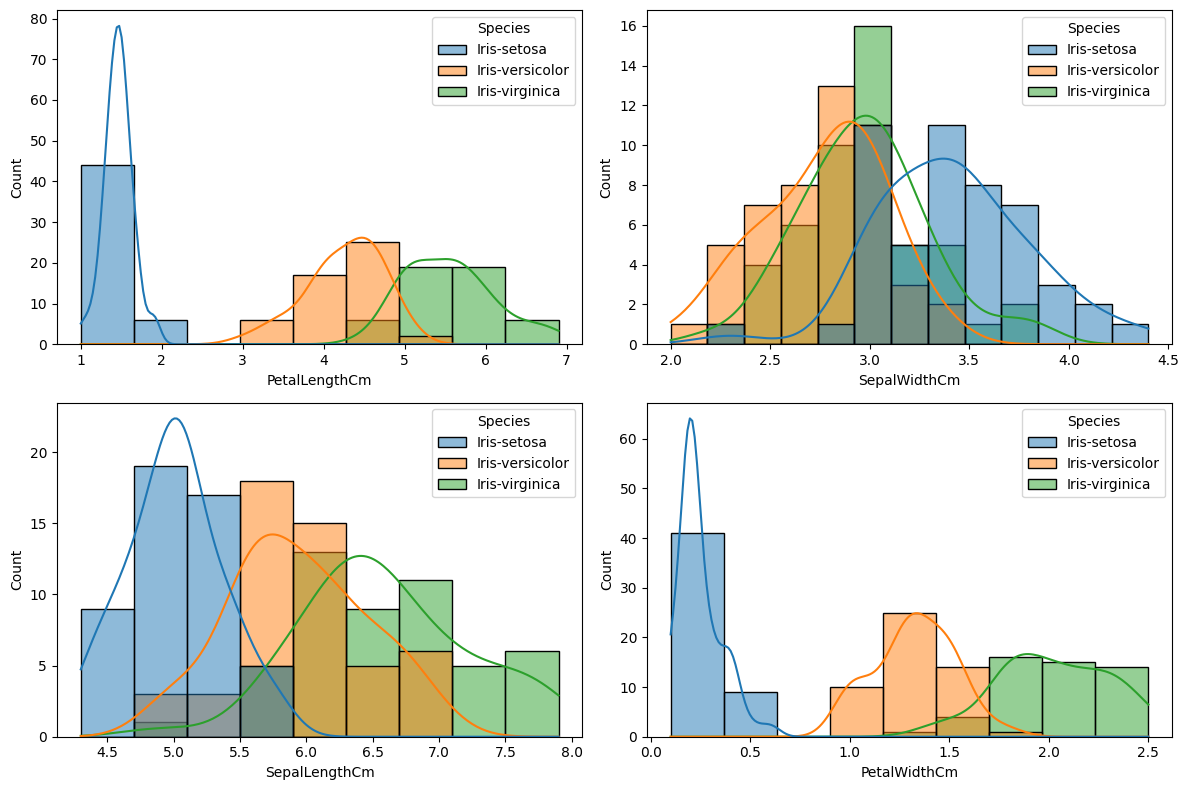

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data = df, x = "PetalLengthCm", kde = True, ax = axes[0, 0], hue="Species") 

sns.histplot(data = df, x = "SepalWidthCm", kde = True, ax = axes[0, 1], hue="Species")  

sns.histplot(data = df, x = "SepalLengthCm", kde = True, ax = axes[1, 0], hue="Species") 

sns.histplot(data = df, x = "PetalWidthCm", kde = True, ax = axes[1, 1], hue="Species")  

plt.tight_layout()
plt.show()

In [11]:
df = df.drop("Id", axis = 1)

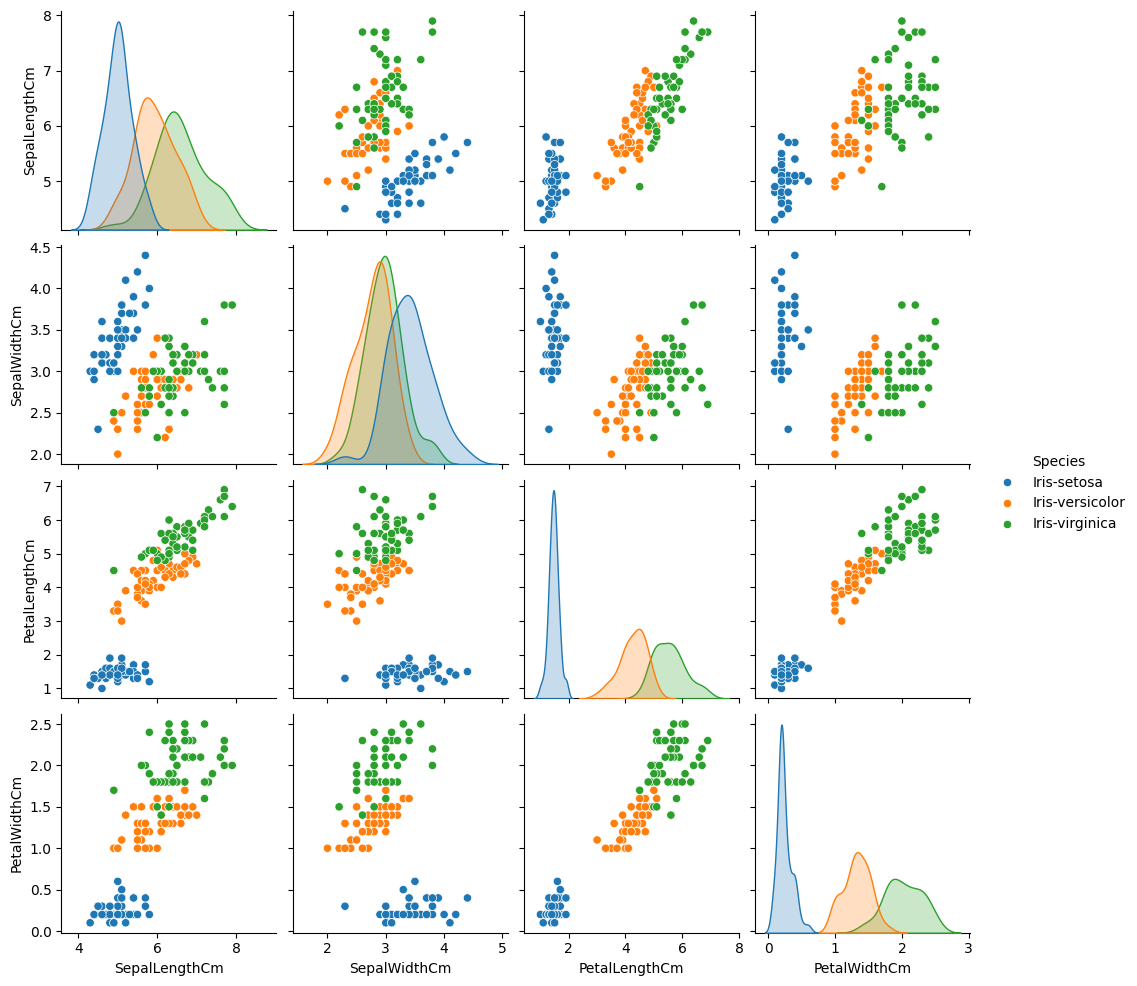

In [12]:
sns.pairplot(df, hue="Species")

<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

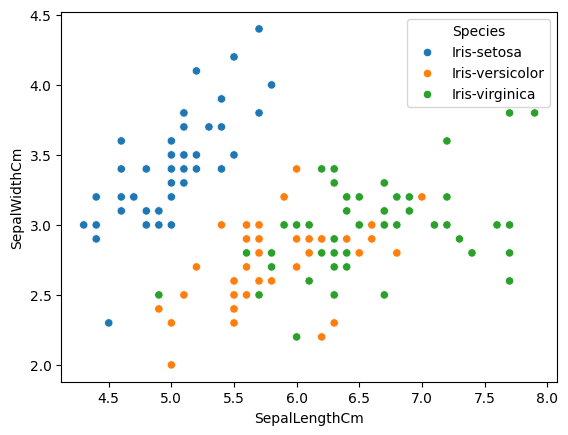

In [13]:
sns.scatterplot(x=df["SepalLengthCm"], y=df["SepalWidthCm"], hue=df["Species"])

<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

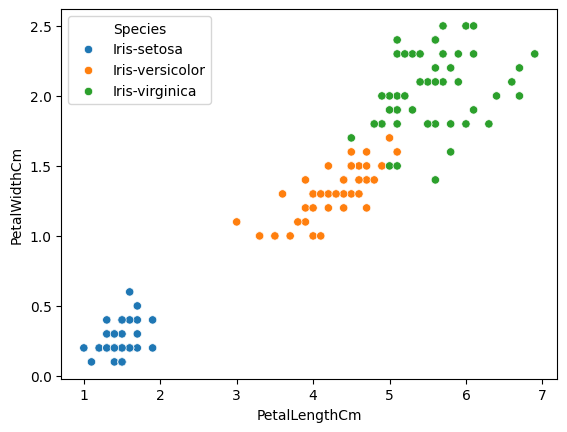

In [14]:
sns.scatterplot(x=df["PetalLengthCm"], y=df["PetalWidthCm"], hue=df["Species"])

In [15]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


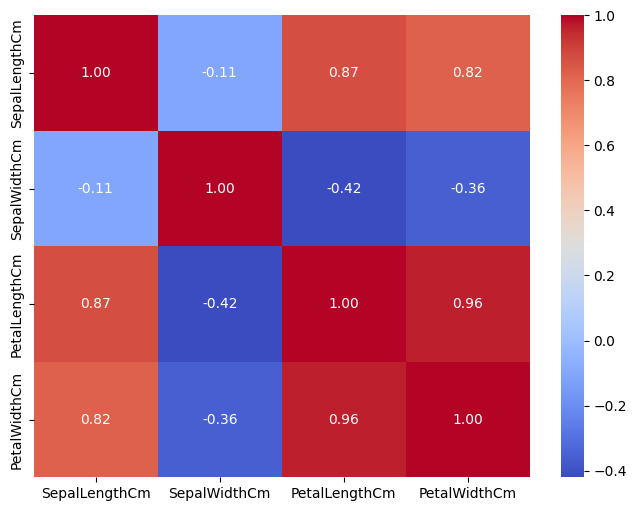

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")

plt.show()

<Axes: xlabel='Species', ylabel='count'>

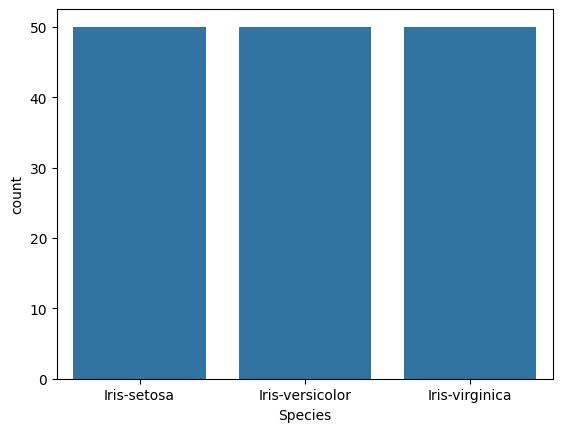

In [17]:
sns.countplot(data=df, x="Species")

In [18]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

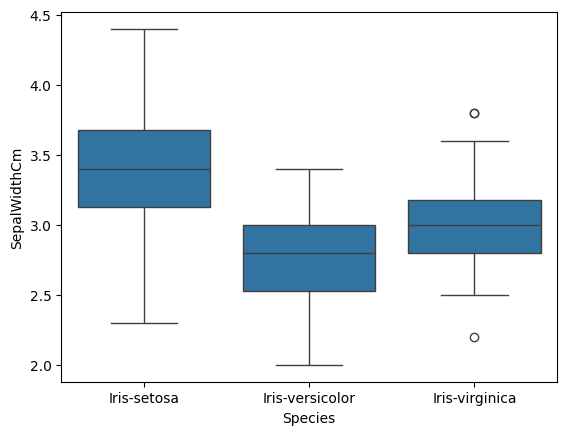

In [19]:
sns.boxplot(data=df, x="Species", y="SepalWidthCm")

<Axes: xlabel='Species', ylabel='SepalLengthCm'>

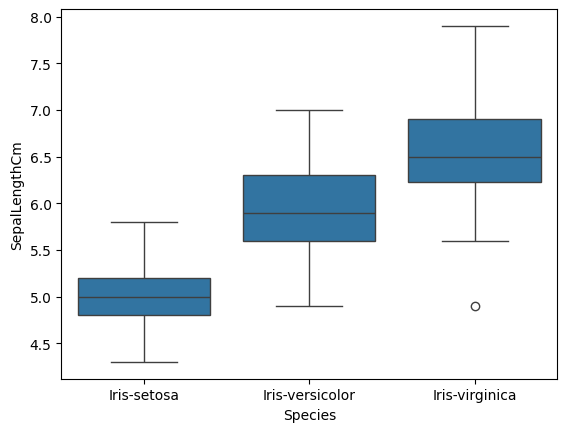

In [20]:
sns.boxplot(data=df, x="Species", y="SepalLengthCm")

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

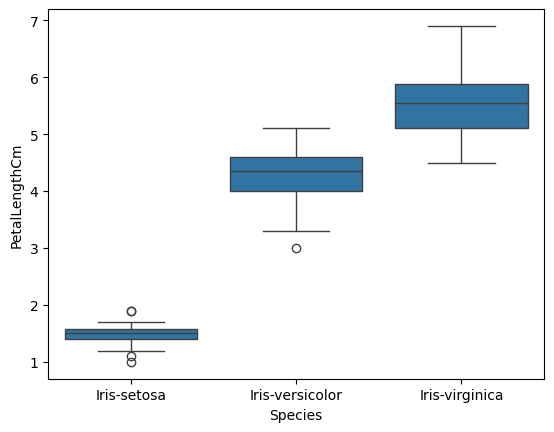

In [21]:
sns.boxplot(data=df, x="Species", y="PetalLengthCm")

<Axes: xlabel='Species', ylabel='PetalWidthCm'>

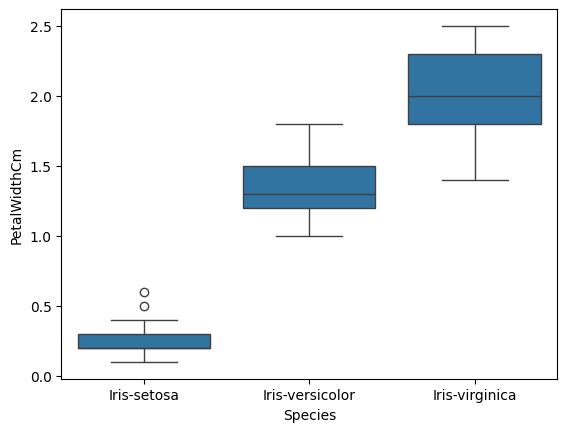

In [22]:
sns.boxplot(data=df, x="Species", y="PetalWidthCm")

In [23]:
df["PetalArea"] = df["PetalLengthCm"] * df["PetalWidthCm"]

In [24]:
X = df.drop("Species", axis=1)

In [25]:
y = df["Species"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# matplotlib

/var/folders/h5/swlzny612n16xym3ymfjfzsh0000gn/T/ipykernel_2915/2979463515.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Species", y="PetalArea", ax=ax[1], palette="viridis", errorbar=None)


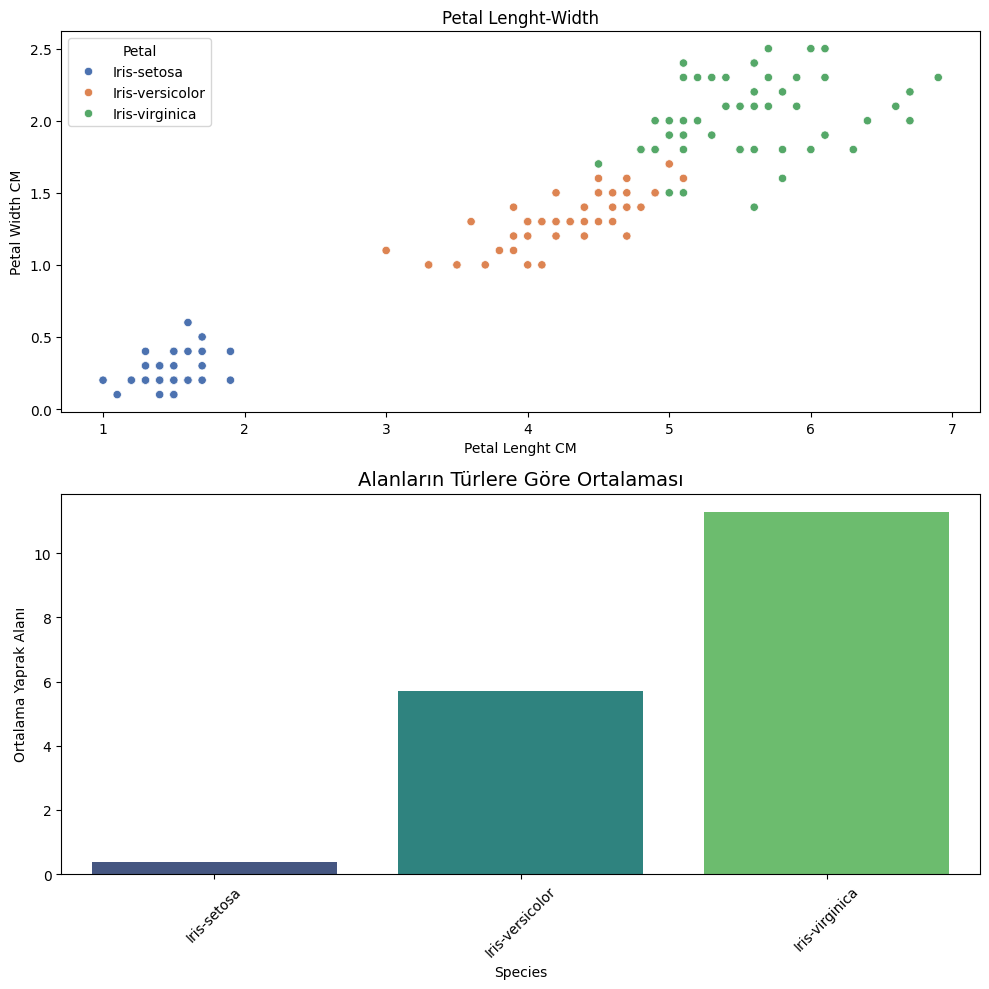

In [29]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10,10))
sns.scatterplot(data=df, x="PetalLengthCm", y="PetalWidthCm", hue="Species", ax=ax[0], palette="deep")
ax[0].set_title("Petal Lenght-Width")
ax[0].set_xlabel("Petal Lenght CM")
ax[0].set_ylabel("Petal Width CM")
ax[0].legend(title= "Petal", loc="upper left")

sns.barplot(data=df, x="Species", y="PetalArea", ax=ax[1], palette="viridis", errorbar=None)
ax[1].set_title("Alanların Türlere Göre Ortalaması", fontsize=14)
ax[1].set_ylabel("Ortalama Yaprak Alanı")
ax[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
#fig.savefig("void_dynamics_iris_analiz_raporu.png", dpi=300, transparent=False)

plt.show()

In [30]:
le = LabelEncoder()

In [31]:
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [42]:
scaler = StandardScaler()

In [43]:
X_train_scaled = scaler.fit_transform(X_train)

In [44]:
X_test_scaled = scaler.transform(X_test)

In [45]:
nb_model = GaussianNB()

In [46]:
nb_model.fit(X_train_scaled, y_train_encoded)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [47]:
y_pred_nb = nb_model.predict(X_test_scaled)

In [52]:
acs = accuracy_score(y_test_encoded, y_pred_nb)
cm = confusion_matrix(y_test_encoded, y_pred_nb)

print(f"Naive Bayes Başarı Oranı (Accuracy): % {acs * 100:.2f}\n")

Naive Bayes Başarı Oranı (Accuracy): % 100.00



In [53]:
rapor_sozluk = classification_report(y_test_encoded, y_pred_nb, 
                                     target_names=le.classes_, output_dict=True)

In [56]:
rapor_df = pd.DataFrame(rapor_sozluk).iloc[:-1, :].T

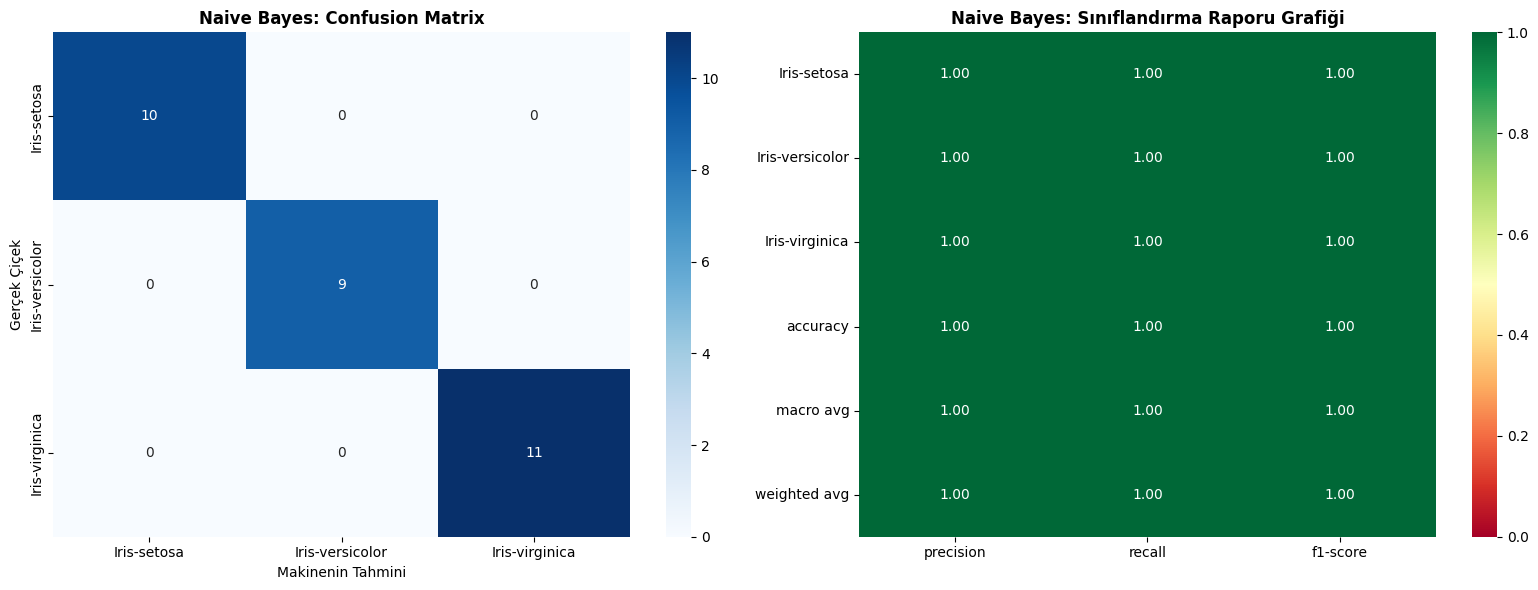

In [66]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0], 
            xticklabels=le.classes_, yticklabels=le.classes_)
ax[0].set_title("Naive Bayes: Confusion Matrix", fontweight="bold")
ax[0].set_ylabel("Gerçek Çiçek")
ax[0].set_xlabel("Makinenin Tahmini")

sns.heatmap(rapor_df, annot=True, cmap="RdYlGn", ax=ax[1], vmin=0, vmax=1, fmt=".2f")
ax[1].set_title("Naive Bayes: Sınıflandırma Raporu Grafiği", fontweight="bold")

plt.tight_layout()
plt.show()

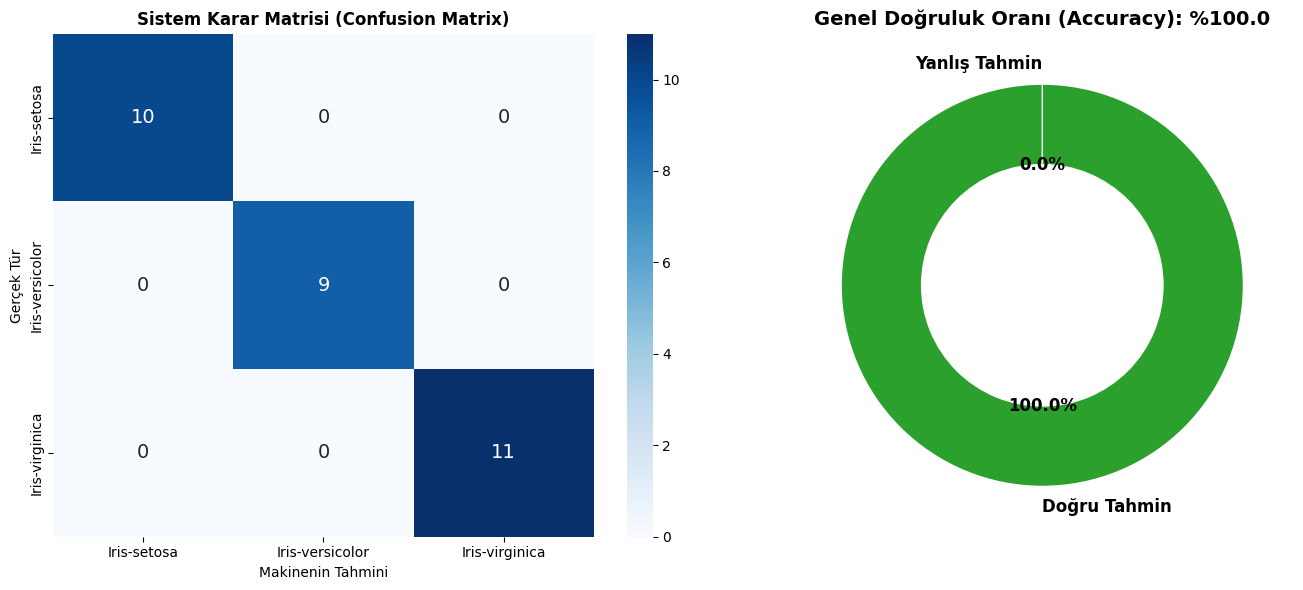

In [74]:
dogru_sayisi = np.trace(cm) 
toplam_soru = cm.sum()
yanlis_sayisi = toplam_soru - dogru_sayisi

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0], 
            xticklabels=le.classes_, yticklabels=le.classes_, annot_kws={"size": 14})
ax[0].set_title("Sistem Karar Matrisi (Confusion Matrix)", fontweight="bold")
ax[0].set_ylabel("Gerçek Tür")
ax[0].set_xlabel("Makinenin Tahmini")

etiketler = ['Doğru Tahmin', 'Yanlış Tahmin']
degerler = [dogru_sayisi, yanlis_sayisi]
renkler = ['#2ca02c', '#d62728']

ax[1].pie(degerler, labels=etiketler, colors=renkler, autopct='%1.1f%%', 
          startangle=90, wedgeprops={'width': 0.4, 'edgecolor': 'w'}, 
          textprops={'fontsize': 12, 'weight': 'bold'})

ax[1].set_title(f"Genel Doğruluk Oranı (Accuracy): %{acs*100:.1f}", fontweight="bold", fontsize=14)

plt.tight_layout()
plt.show()

In [82]:
parametre_agaci = {
    'C': [1],
    'solver': ["lbfgs"],
    'max_iter': [1000]
}

log = LogisticRegression()

grid = GridSearchCV(estimator=log , param_grid=parametre_agaci, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train_encoded)

print("Best Params: ", grid.best_params_)
print("Best Score: ", round(grid.best_score_ * 100, 2))

sonuclar_df = pd.DataFrame(grid.cv_results_)

Best Params:  {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
Best Score:  95.83


In [87]:
svc = SVC(kernel='linear', C=1.0, random_state=15)
svc.fit(X_train_scaled, y_train_encoded)
y_pred_svc = svc.predict(X_test_scaled)
print(classification_report(y_test_encoded, y_pred_svc, target_names=le.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [88]:
from sklearn.metrics import roc_curve, roc_auc_score

In [89]:
model_prob  = grid.predict_proba(X_test)

/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [90]:
model_prob

array([[1.09274138e-15, 1.20436458e-08, 9.99999988e-01],
       [2.74590952e-04, 9.69492254e-01, 3.02331552e-02],
       [1.73214079e-34, 6.12470375e-24, 1.00000000e+00],
       [3.81612447e-17, 3.85620261e-10, 1.00000000e+00],
       [7.67368710e-18, 3.62862789e-10, 1.00000000e+00],
       [2.83778860e-04, 9.50891820e-01, 4.88244009e-02],
       [8.87503441e-13, 8.54054420e-07, 9.99999146e-01],
       [8.24235591e-26, 2.34419644e-17, 1.00000000e+00],
       [7.38280962e-18, 2.44221565e-10, 1.00000000e+00],
       [2.57690277e-13, 5.85853426e-07, 9.99999414e-01],
       [4.05848548e-23, 3.49805608e-15, 1.00000000e+00],
       [7.13180391e-04, 9.88358762e-01, 1.09280573e-02],
       [5.35205171e-04, 9.90280735e-01, 9.18405958e-03],
       [6.07546600e-04, 9.87599136e-01, 1.17933176e-02],
       [8.54438550e-04, 9.76939765e-01, 2.22057967e-02],
       [2.40221864e-18, 3.57037709e-11, 1.00000000e+00],
       [7.29865540e-28, 3.80613251e-19, 1.00000000e+00],
       [9.43407974e-13, 1.80104

In [91]:
model_prob = model_prob[:,1] # probabilities for the positive (fraud) class

In [92]:
model_prob

array([1.20436458e-08, 9.69492254e-01, 6.12470375e-24, 3.85620261e-10,
       3.62862789e-10, 9.50891820e-01, 8.54054420e-07, 2.34419644e-17,
       2.44221565e-10, 5.85853426e-07, 3.49805608e-15, 9.88358762e-01,
       9.90280735e-01, 9.87599136e-01, 9.76939765e-01, 3.57037709e-11,
       3.80613251e-19, 1.80104807e-06, 6.65626793e-09, 1.60009915e-18,
       9.73834119e-01, 3.07644843e-13, 9.30591986e-01, 9.95528390e-18,
       4.90523740e-19, 9.00129441e-18, 5.30533660e-16, 3.12690197e-20,
       9.65977007e-01, 9.72792843e-01])

In [93]:
model_auc = (y_test, model_prob)

In [94]:
model_auc

(73     Iris-versicolor
 18         Iris-setosa
 118     Iris-virginica
 78     Iris-versicolor
 76     Iris-versicolor
 31         Iris-setosa
 64     Iris-versicolor
 141     Iris-virginica
 68     Iris-versicolor
 82     Iris-versicolor
 110     Iris-virginica
 12         Iris-setosa
 36         Iris-setosa
 9          Iris-setosa
 19         Iris-setosa
 56     Iris-versicolor
 104     Iris-virginica
 69     Iris-versicolor
 55     Iris-versicolor
 132     Iris-virginica
 29         Iris-setosa
 127     Iris-virginica
 26         Iris-setosa
 128     Iris-virginica
 131     Iris-virginica
 145     Iris-virginica
 108     Iris-virginica
 143     Iris-virginica
 45         Iris-setosa
 30         Iris-setosa
 Name: Species, dtype: object,
 array([1.20436458e-08, 9.69492254e-01, 6.12470375e-24, 3.85620261e-10,
        3.62862789e-10, 9.50891820e-01, 8.54054420e-07, 2.34419644e-17,
        2.44221565e-10, 5.85853426e-07, 3.49805608e-15, 9.88358762e-01,
        9.90280735e-01, 9.8759913

In [99]:
y_test_bin = label_binarize(y_test_encoded, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

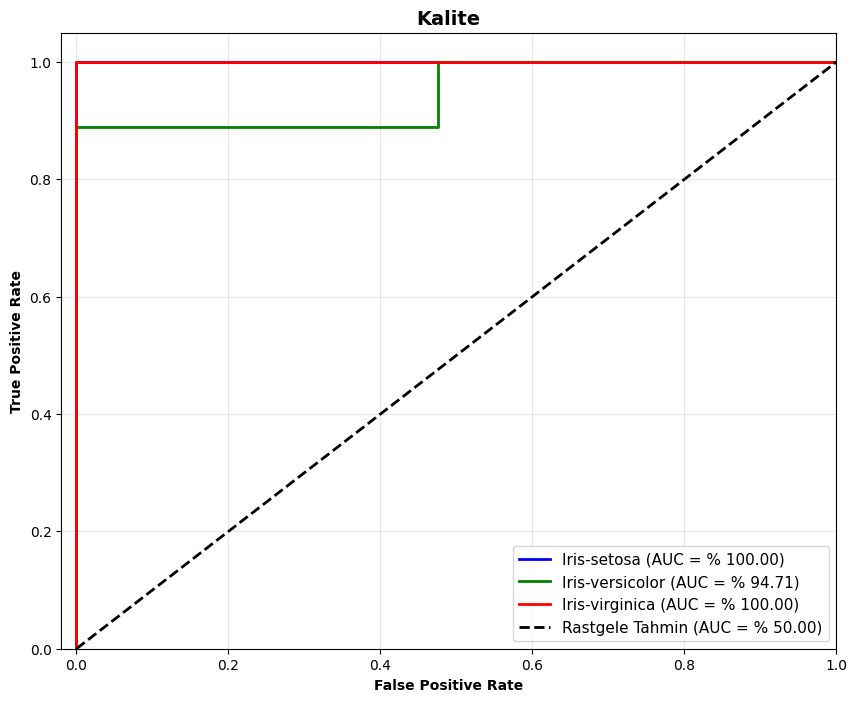

In [105]:
y_score = svc.decision_function(X_test_scaled)
fig, ax = plt.subplots(figsize=(10, 8))
renkler = ['blue', 'green', 'red']
for i, color in zip(range(n_classes), renkler):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    auc_skoru = roc_auc_score(y_test_bin[:, i], y_score[:, i])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{le.classes_[i]} (AUC = % {auc_skoru*100:.2f})")
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Rastgele Tahmin (AUC = % 50.00)')  
ax.set_xlim([-0.02, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('Kalite', fontweight='bold', fontsize=14)
ax.legend(loc="lower right", fontsize=11)

# Ekrana bas
plt.grid(alpha=0.3)
plt.show()

In [108]:
for i in range(3):
    model_fpr, model_tpr, thresholds = roc_curve(y_test_bin[:, i], y_score[:, i])
    
    model_auc = auc(model_fpr, model_tpr)
    
    print(f"{le.classes_[i]} Sınıfı için Başarı (AUC): % {model_auc * 100:.2f}")

Iris-setosa Sınıfı için Başarı (AUC): % 100.00
Iris-versicolor Sınıfı için Başarı (AUC): % 94.71
Iris-virginica Sınıfı için Başarı (AUC): % 100.00


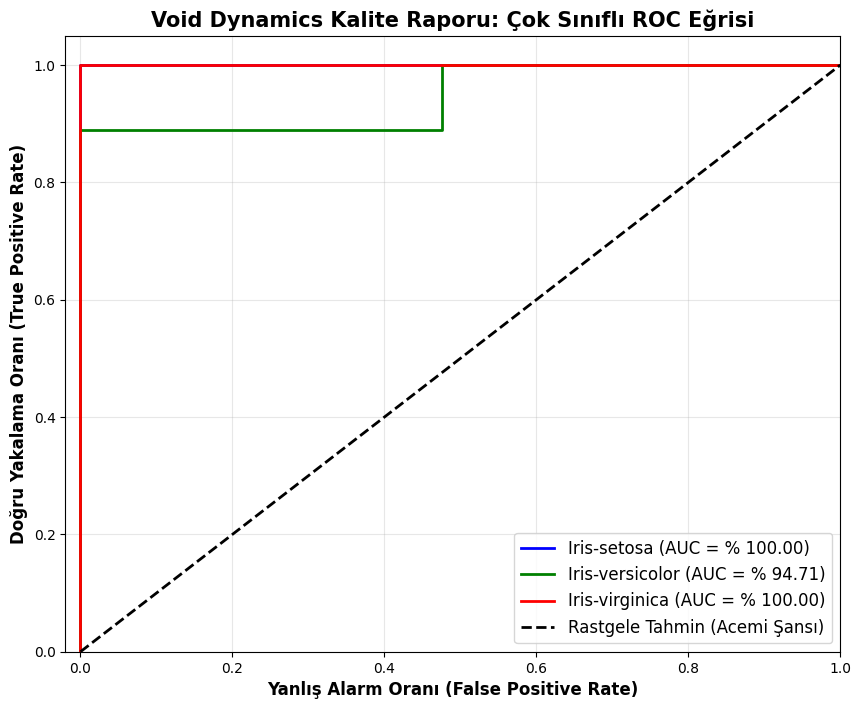

In [109]:
fig, ax = plt.subplots(figsize=(10, 8))
renkler = ['blue', 'green', 'red']

for i, color in zip(range(3), renkler):
    model_fpr, model_tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    model_auc = auc(model_fpr, model_tpr)
    
    ax.plot(model_fpr, model_tpr, color=color, lw=2,
            label=f"{le.classes_[i]} (AUC = % {model_auc*100:.2f})")

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Rastgele Tahmin (Acemi Şansı)')

ax.set_xlim([-0.02, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Yanlış Alarm Oranı (False Positive Rate)', fontweight='bold', fontsize=12)
ax.set_ylabel('Doğru Yakalama Oranı (True Positive Rate)', fontweight='bold', fontsize=12)
ax.set_title('Void Dynamics Kalite Raporu: Çok Sınıflı ROC Eğrisi', fontweight='bold', fontsize=15)
ax.legend(loc="lower right", fontsize=12)

plt.grid(alpha=0.3)
plt.show()